# Laboratorio 2 - Complejidad y búsqueda de hiperparámetros

## Integrantes

Santiago Tenjo 202113965

Ali Cifci 202210698

---

En el Laboratorio 1 construimos un modelo de regresión lineal para estimar la temperatura máxima
del día siguiente en la estación de Jena. Acá evaluamos enfoques más complejos (polinomial y
regularizado), buscamos los hiperparámetros con `GridSearchCV` y cuantificamos la incertidumbre
del mejor modelo con bootstrapping.

Como pide el enunciado, partimos del **conjunto ya limpio y preparado del Laboratorio 1**, no de
los datos crudos.

# Importacion de librerias

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import GridSearchCV, validation_curve, train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## Carga de datos

Traemos las funciones `limpiar()` e `ingenieria()` tal como quedaron en el Laboratorio 1. Sin este
paso los modelos entrenarían sobre los centinelas −9999, las presiones de 9939 mbar y las 29
variantes de `estacion_anio`, y con `PolynomialFeatures` esos valores se elevan al cuadrado y
rompen cualquier modelo.

In [2]:
datos_lab = pd.read_csv('Datos_Lab_1.csv')
diccionario = pd.read_excel('Diccionario_de_datos.xlsx')

In [3]:
MAPEO_SECTOR = {
    'n':'N',  'norte':'N',    'north':'N',
    'ne':'NE','noreste':'NE', 'northeast':'NE',
    'e':'E',  'este':'E',     'east':'E',
    'se':'SE','sureste':'SE', 'southeast':'SE',
    's':'S',  'sur':'S',      'south':'S',
    'so':'SO','suroeste':'SO','southwest':'SO',
    'o':'O',  'oeste':'O',    'west':'O',
    'no':'NO','noroeste':'NO','northwest':'NO',
}

RANGOS_VALIDOS = {
    'presion_media':(870,1085), 'presion_min':(870,1085), 'presion_max':(870,1085),
    'presion_desv':(0,40),
    'humedad_media':(5,100),    'humedad_min':(5,100),    'humedad_max':(20,100),
    'humedad_desv':(0,60),
    'viento_media':(0,60),      'viento_min':(0,60),      'viento_max':(0,80),
    'viento_desv':(0,40),
    'rafaga_media':(0,80),      'rafaga_min':(0,80),      'rafaga_max':(0,100),
    'rafaga_desv':(0,40),
    'viento_norte':(-60,60),    'viento_este':(-60,60),
    'direccion_viento':(0,360), 'registros_del_dia':(1,144),
}

In [4]:
def limpiar(df):
    """Limpieza del Laboratorio 1: fecha, consistencia de categóricas y validez de rangos."""
    d = df.copy()

    # Fecha: el entrenamiento usa AAAA-MM-DD y el test DD.MM.AAAA
    formato_iso = pd.to_datetime(d['fecha'], format='%Y-%m-%d', errors='coerce')
    formato_dmy = pd.to_datetime(d['fecha'], format='%d.%m.%Y', errors='coerce')
    d['fecha'] = formato_iso.fillna(formato_dmy)

    # Consistencia del sector del viento
    d['sector_viento'] = d['sector_viento'].str.strip().str.lower().map(MAPEO_SECTOR)

    # Humedades guardadas como fracción en vez de porcentaje
    for c in ['humedad_media', 'humedad_min', 'humedad_max']:
        d.loc[d[c] <= 1.5, c] = d.loc[d[c] <= 1.5, c] * 100

    # Centinela y valores fuera del rango físicamente posible
    d = d.replace(-9999, np.nan)
    for c, (bajo, alto) in RANGOS_VALIDOS.items():
        d.loc[~d[c].between(bajo, alto), c] = np.nan
    if 'temp_max_manana' in d.columns:
        d.loc[~d['temp_max_manana'].between(-30, 45), 'temp_max_manana'] = np.nan

    # Variables de tiempo reconstruidas desde la fecha
    d['dia_del_anio'] = d['fecha'].dt.dayofyear.fillna(d['dia_del_anio'])
    d['mes'] = d['fecha'].dt.month_name()
    estaciones = pd.cut(d['dia_del_anio'], bins=[0, 79, 171, 264, 355, 367],
                        labels=['invierno','primavera','verano','otono','invierno '], ordered=False)
    d['estacion_anio'] = estaciones.astype(object).str.strip()
    return d


def ingenieria(d):
    """Variables derivadas del Laboratorio 1: rangos diarios y codificación cíclica."""
    d = d.copy()
    d['presion_rango'] = d['presion_max'] - d['presion_min']
    d['humedad_rango'] = d['humedad_max'] - d['humedad_min']
    d['dia_sin'] = np.sin(2 * np.pi * d['dia_del_anio'] / 365)
    d['dia_cos'] = np.cos(2 * np.pi * d['dia_del_anio'] / 365)
    d['dir_sin'] = np.sin(np.radians(d['direccion_viento']))
    d['dir_cos'] = np.cos(np.radians(d['direccion_viento']))
    return d

In [5]:
data = ingenieria(limpiar(datos_lab))
data = data.drop_duplicates().drop_duplicates(subset=['fecha'], keep='first')
data = data.dropna(subset=['temp_max_manana'])

TARGET_COL = 'temp_max_manana'
# 'anio' se excluye porque es constante en el conjunto no etiquetado (Lab 1)
X = data.drop(columns=[TARGET_COL, 'fecha', 'anio'])
y = data[TARGET_COL]

# Mismos parámetros de partición que el Laboratorio 1, para que los resultados sean comparables
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

columnas_numericas = X.select_dtypes(include=[np.number]).columns.tolist()
columnas_categoricas = [c for c in X.columns if c not in columnas_numericas]

print(f"Registros: {len(X)}  ->  {len(X_train)} train / {len(X_test)} test")
print(f"Variables numéricas  : {len(columnas_numericas)}")
print(f"Variables categóricas: {columnas_categoricas}")
print(f"Categorías por variable: "
      f"{ {c: X[c].nunique() for c in columnas_categoricas} }")

Registros: 2392  ->  1794 train / 598 test
Variables numéricas  : 27
Variables categóricas: ['estacion_anio', 'mes', 'sector_viento']
Categorías por variable: {'estacion_anio': 4, 'mes': 12, 'sector_viento': 8}


### Preprocesador

Una diferencia respecto al Lab 1: `PolynomialFeatures` va **dentro del transformador numérico**, no
después del `ColumnTransformer`. Si fuera después también expandiría las variables dummy del
One-Hot, generando productos entre indicadores que no aportan nada y multiplicando el costo.

Dejamos el escalador como un paso con nombre (`scaler`) para poder buscarlo como hiperparámetro,
que es lo que pide el enunciado.

In [6]:
def construir_preprocesador():
    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('poly', PolynomialFeatures(degree=1, include_bias=False)),
        ('scaler', StandardScaler()),
    ])
    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first')),
    ])
    return ColumnTransformer(transformers=[
        ('num', numeric_transformer, columnas_numericas),
        ('cat', categorical_transformer, columnas_categoricas),
    ])

# Estrategias de escalamiento que van a entrar en la búsqueda
ESCALADORES = [StandardScaler(), MinMaxScaler()]

# El enunciado pide reportar las tres métricas por validación cruzada.
# Optimizamos por RMSE (refit) pero registramos también MAE y R2.
METRICAS = {
    'RMSE': 'neg_root_mean_squared_error',
    'MAE': 'neg_mean_absolute_error',
    'R2': 'r2',
}

## Regresion polinomial

Buscamos el grado del polinomio y la estrategia de escalamiento con `GridSearchCV` y 5 pliegues.
Registramos **RMSE, MAE y R²** en validación cruzada como pide el enunciado, y optimizamos por RMSE
(`refit='RMSE'`), que es la métrica principal por estar en las mismas unidades que la temperatura. Guardamos también el score de entrenamiento
(`return_train_score=True`) porque la diferencia entre train y validación es lo que delata el
sobreajuste.

In [7]:
pipe_poly = Pipeline([
    ('preprocessor', construir_preprocesador()),
    ('regressor', LinearRegression())
])

param_grid_poly = {
    'preprocessor__num__poly__degree': [1, 2, 3],
    'preprocessor__num__scaler': ESCALADORES,
}

grid_poly = GridSearchCV(
    estimator=pipe_poly,
    param_grid=param_grid_poly,
    scoring=METRICAS,
    refit='RMSE',
    cv=5,
    n_jobs=-1,
    return_train_score=True
)
grid_poly.fit(X_train, y_train)

i = grid_poly.best_index_
print("--- ACT 1: Mejor Regresión Polinomial ---")
print("Mejores Hiperparámetros:", grid_poly.best_params_)
print(f"RMSE en CV: {-grid_poly.cv_results_['mean_test_RMSE'][i]:.3f} °C")
print(f"MAE  en CV: {-grid_poly.cv_results_['mean_test_MAE'][i]:.3f} °C")
print(f"R2   en CV: {grid_poly.cv_results_['mean_test_R2'][i]:.3f}")

--- ACT 1: Mejor Regresión Polinomial ---
Mejores Hiperparámetros: {'preprocessor__num__poly__degree': 1, 'preprocessor__num__scaler': StandardScaler()}
RMSE en CV: 4.381 °C
MAE  en CV: 3.411 °C
R2   en CV: 0.770


In [8]:
def tabla_grid(grid, columnas):
    """Resumen legible de un GridSearchCV, con las tres métricas en validación cruzada."""
    r = pd.DataFrame(grid.cv_results_)
    t = pd.DataFrame({
        **{c.split('__')[-1]: r['param_' + c].astype(str) for c in columnas},
        'RMSE train': -r['mean_train_RMSE'],
        'RMSE CV': -r['mean_test_RMSE'],
        'Desv. RMSE': r['std_test_RMSE'],
        'MAE CV': -r['mean_test_MAE'],
        'R2 CV': r['mean_test_R2'],
    })
    return t.sort_values('RMSE CV').reset_index(drop=True)

tabla_grid(grid_poly, list(param_grid_poly.keys())).round(3)

,degree,scaler,RMSE train,RMSE CV,Desv. RMSE,MAE CV,R2 CV
0,1,StandardScaler(),4.229,4.381,0.099,3.411,0.770
1,1,MinMaxScaler(),4.229,4.381,0.099,3.411,0.770
2,2,MinMaxScaler(),3.177,11.837,4.761,4.441,-1.035
3,2,StandardScaler(),3.177,13.598,6.050,4.596,-1.767
4,3,MinMaxScaler(),0.000,102.266,20.329,32.585,-131.242
5,3,StandardScaler(),0.000,149.446,13.208,38.787,-271.738


El resultado ya dice algo importante: la búsqueda elige **grado 1**, es decir, el modelo lineal de
siempre. Subir a grado 2 multiplica por tres el error de validación y el grado 3 lo vuelve
inservible. En grado 1 el escalador es indiferente (4.381 con los dos), pero en los grados altos sí
importa, porque cambia la escala en la que quedan los términos cuadráticos y cúbicos.

## Curvas de validacion

Para ver el efecto de la complejidad con más detalle, graficamos el error de entrenamiento y el de
validación en función del grado.

In [9]:
grados = [1, 2, 3]

train_scores, val_scores = validation_curve(
    Pipeline([('preprocessor', construir_preprocesador()), ('regressor', LinearRegression())]),
    X_train, y_train,
    param_name='preprocessor__num__poly__degree',
    param_range=grados,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

rmse_train, rmse_val = -train_scores, -val_scores

for g, a, b in zip(grados, rmse_train.mean(axis=1), rmse_val.mean(axis=1)):
    print(f"grado {g}:  RMSE train = {a:8.3f}   RMSE validación = {b:10.3f}")

grado 1:  RMSE train =    4.229   RMSE validación =      4.381
grado 2:  RMSE train =    3.177   RMSE validación =     13.598
grado 3:  RMSE train =    0.000   RMSE validación =    149.446


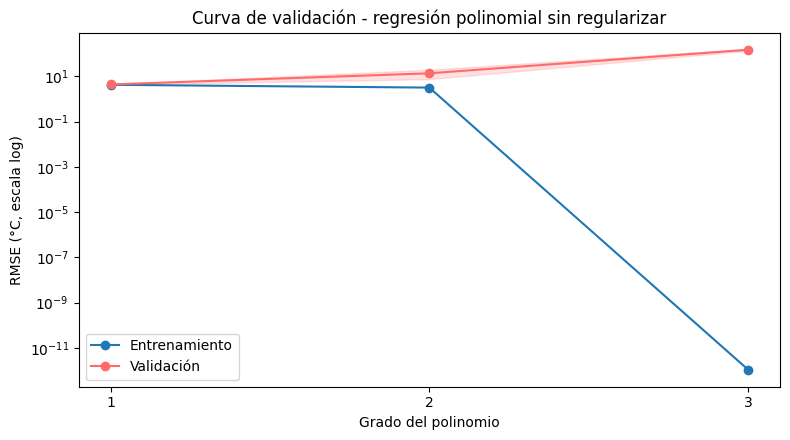

In [10]:
plt.figure(figsize=(8,4.5))
plt.plot(grados, rmse_train.mean(axis=1), 'o-', label='Entrenamiento')
plt.fill_between(grados, rmse_train.mean(axis=1) - rmse_train.std(axis=1),
                 rmse_train.mean(axis=1) + rmse_train.std(axis=1), alpha=0.2)
plt.plot(grados, rmse_val.mean(axis=1), 'o-', color='#FF6B6B', label='Validación')
plt.fill_between(grados, rmse_val.mean(axis=1) - rmse_val.std(axis=1),
                 rmse_val.mean(axis=1) + rmse_val.std(axis=1), alpha=0.2, color='#FF6B6B')
plt.yscale('log')
plt.xticks(grados)
plt.xlabel('Grado del polinomio')
plt.ylabel('RMSE (°C, escala log)')
plt.title('Curva de validación - regresión polinomial sin regularizar')
plt.legend()
plt.tight_layout()
plt.show()

La curva es un caso de manual del trade-off sesgo-varianza:

- **Grado 1:** train 4.23 y validación 4.38. La brecha es mínima, el modelo generaliza.
- **Grado 2:** el error de entrenamiento baja a 3.18 pero el de validación se dispara a 13.6. **Acá
  ya empieza el sobreajuste.**
- **Grado 3:** el RMSE de entrenamiento llega a **0.000** y el de validación a 149. Con 27 variables
  numéricas, el grado 3 genera 4080 columnas para 1794 registros de entrenamiento: hay más
  parámetros que datos, así que el modelo memoriza el train exactamente y no aprende nada.

Es decir, el sobreajuste aparece **desde el grado 2** y se vuelve total en el 3. Sin algún mecanismo
que controle la varianza, aumentar la complejidad solo empeora las cosas.

## Modelos Regularizados (Ridge y Lasso)

Ahora mantenemos el grado en 1 y buscamos el parámetro de penalización junto con el escalador.
Ridge (L2) encoge los coeficientes hacia cero; Lasso (L1) puede llevarlos exactamente a cero, lo
que equivale a una selección automática de variables.

In [11]:
# Ridge
pipe_ridge = Pipeline([
    ('preprocessor', construir_preprocesador()),
    ('regressor', Ridge())
])
param_grid_ridge = {
    'regressor__alpha': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],
    'preprocessor__num__scaler': ESCALADORES,
}
grid_ridge = GridSearchCV(pipe_ridge, param_grid_ridge, scoring=METRICAS, refit='RMSE',
                          cv=5, n_jobs=-1, return_train_score=True)
grid_ridge.fit(X_train, y_train)

# Lasso
pipe_lasso = Pipeline([
    ('preprocessor', construir_preprocesador()),
    ('regressor', Lasso(max_iter=20000))
])
param_grid_lasso = {
    'regressor__alpha': [0.001, 0.01, 0.1, 1.0],
    'preprocessor__num__scaler': ESCALADORES,
}
grid_lasso = GridSearchCV(pipe_lasso, param_grid_lasso, scoring=METRICAS, refit='RMSE',
                          cv=5, n_jobs=-1, return_train_score=True)
grid_lasso.fit(X_train, y_train)

def resumen_cv(grid, nombre):
    i = grid.best_index_
    print(f"{nombre}: {grid.best_params_}")
    print(f"   RMSE CV = {-grid.cv_results_['mean_test_RMSE'][i]:.3f} °C | "
          f"MAE CV = {-grid.cv_results_['mean_test_MAE'][i]:.3f} °C | "
          f"R2 CV = {grid.cv_results_['mean_test_R2'][i]:.3f}")

print("--- ACT 3: Modelos Regularizados ---")
resumen_cv(grid_ridge, "Mejor Ridge")
resumen_cv(grid_lasso, "Mejor Lasso")

--- ACT 3: Modelos Regularizados ---
Mejor Ridge: {'preprocessor__num__scaler': MinMaxScaler(), 'regressor__alpha': 1.0}
   RMSE CV = 4.370 °C | MAE CV = 3.398 °C | R2 CV = 0.771
Mejor Lasso: {'preprocessor__num__scaler': MinMaxScaler(), 'regressor__alpha': 0.01}
   RMSE CV = 4.355 °C | MAE CV = 3.371 °C | R2 CV = 0.772


In [12]:
tabla_grid(grid_ridge, list(param_grid_ridge.keys())).head(6).round(3)

,alpha,scaler,RMSE train,RMSE CV,Desv. RMSE,MAE CV,R2 CV
0,1.0,MinMaxScaler(),4.242,4.370,0.100,3.398,0.771
1,10.0,StandardScaler(),4.245,4.371,0.086,3.394,0.771
2,1.0,StandardScaler(),4.231,4.375,0.094,3.405,0.770
3,0.1,MinMaxScaler(),4.230,4.377,0.099,3.407,0.770
4,0.1,StandardScaler(),4.229,4.380,0.098,3.409,0.770
5,0.01,MinMaxScaler(),4.229,4.381,0.099,3.410,0.770


### Efecto de la penalización sobre los coeficientes

In [13]:
def resumen_coeficientes(modelo, nombre):
    p = Pipeline([('preprocessor', construir_preprocesador()), ('regressor', modelo)])
    p.fit(X_train, y_train)
    coef = p.named_steps['regressor'].coef_
    return {
        'Modelo': nombre,
        '|coef| máximo': np.abs(coef).max(),
        '|coef| promedio': np.abs(coef).mean(),
        'Coeficientes en cero': int((np.abs(coef) < 1e-8).sum()),
        'Total coeficientes': len(coef),
    }

comparacion_coef = pd.DataFrame([
    resumen_coeficientes(LinearRegression(), 'Sin regularizar (MCO)'),
    resumen_coeficientes(Ridge(alpha=grid_ridge.best_params_['regressor__alpha']),
                         f"Ridge (alpha={grid_ridge.best_params_['regressor__alpha']})"),
    resumen_coeficientes(Lasso(alpha=grid_lasso.best_params_['regressor__alpha'], max_iter=20000),
                         f"Lasso (alpha={grid_lasso.best_params_['regressor__alpha']})"),
]).set_index('Modelo')

comparacion_coef.round(3)

,|coef| máximo,|coef| promedio,Coeficientes en cero,Total coeficientes
Modelo,,,,
Sin regularizar (MCO),8.503,1.039,0,48
Ridge (alpha=1.0),7.933,0.864,0,48
Lasso (alpha=0.01),7.229,0.529,9,48


### Variables que Lasso lleva a cero

In [14]:
pipe_lasso_final = Pipeline([
    ('preprocessor', construir_preprocesador()),
    ('regressor', Lasso(alpha=grid_lasso.best_params_['regressor__alpha'], max_iter=20000))
])
pipe_lasso_final.fit(X_train, y_train)

nombres = [n.split('__')[-1] for n in
           pipe_lasso_final.named_steps['preprocessor'].get_feature_names_out()]
coef_lasso = pd.DataFrame({
    'Variable': nombres,
    'Coeficiente': pipe_lasso_final.named_steps['regressor'].coef_
})

anuladas = coef_lasso[coef_lasso['Coeficiente'].abs() < 1e-8]
print(f"Variables anuladas: {len(anuladas)} de {len(coef_lasso)}")
print(anuladas['Variable'].tolist())
print()
print("Las 8 que más pesan:")
print(coef_lasso.reindex(coef_lasso['Coeficiente'].abs()
      .sort_values(ascending=False).index).head(8).to_string(index=False))

Variables anuladas: 9 de 48
['presion_min', 'direccion_viento', 'estacion_anio_verano', 'mes_August', 'mes_December', 'mes_January', 'mes_March', 'mes_October', 'sector_viento_O']

Las 8 que más pesan:
     Variable  Coeficiente
      dia_cos    -7.229225
     mes_June    -2.316547
      mes_May    -2.228089
 viento_norte    -1.768720
      dia_sin    -1.204036
      dir_sin     1.162376
humedad_media    -1.123293
 mes_November     0.929315


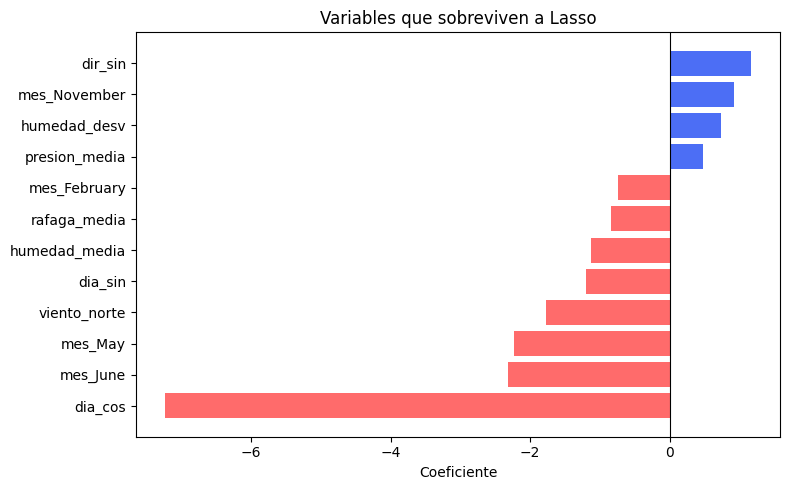

In [15]:
top = coef_lasso.reindex(coef_lasso['Coeficiente'].abs().sort_values(ascending=False).index)
top = top.head(12).sort_values('Coeficiente')
colores = ['#FF6B6B' if c < 0 else '#4C6EF5' for c in top['Coeficiente']]

plt.figure(figsize=(8,5))
plt.barh(top['Variable'], top['Coeficiente'], color=colores)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coeficiente')
plt.title('Variables que sobreviven a Lasso')
plt.tight_layout()
plt.show()

Dos cosas que vale la pena leer con calma:

**La penalización sí encoge los coeficientes.** El coeficiente promedio en valor absoluto baja de
1.04 sin regularizar a 0.86 con Ridge y a 0.53 con Lasso. Ridge los acerca a cero pero no los anula;
Lasso deja **9 de 48 exactamente en cero**.

**Lo que Lasso descarta tiene sentido.** Anula seis dummies de `mes` y la variable
`estacion_anio_verano`, que es justo la información que ya está contenida en `dia_sin` y `dia_cos`.
También anula `presion_min`, que es casi colineal con `presion_media` y `presion_max`. O sea, Lasso
está encontrando por su cuenta la redundancia que en el Lab 1 detectamos a mano con el VIF. De
hecho, el coeficiente más grande que conserva es `dia_cos`, lo mismo que concluimos allá.

## Polinomial Regularizado

Acá está la pregunta interesante: si el grado 3 destruía el modelo sin regularización, ¿la
penalización permite recuperarlo? Buscamos grado, alpha y escalador a la vez.

In [16]:
pipe_poly_ridge = Pipeline([
    ('preprocessor', construir_preprocesador()),
    ('regressor', Ridge())
])

param_grid_poly_ridge = {
    'preprocessor__num__poly__degree': [1, 2, 3],
    'regressor__alpha': [1.0, 10.0, 100.0, 1000.0],
    'preprocessor__num__scaler': ESCALADORES,
}

grid_poly_ridge = GridSearchCV(
    estimator=pipe_poly_ridge,
    param_grid=param_grid_poly_ridge,
    scoring=METRICAS,
    refit='RMSE',
    cv=5,
    n_jobs=-1,
    return_train_score=True
)
grid_poly_ridge.fit(X_train, y_train)

print("--- ACT 4: Polinomial Regularizado ---")
resumen_cv(grid_poly_ridge, "Mejor Polinomial + Ridge")

--- ACT 4: Polinomial Regularizado ---
Mejor Polinomial + Ridge: {'preprocessor__num__poly__degree': 3, 'preprocessor__num__scaler': MinMaxScaler(), 'regressor__alpha': 10.0}
   RMSE CV = 3.995 °C | MAE CV = 3.067 °C | R2 CV = 0.808


In [17]:
tabla_grid(grid_poly_ridge, list(param_grid_poly_ridge.keys())).head(8).round(3)

,degree,alpha,scaler,RMSE train,RMSE CV,Desv. RMSE,MAE CV,R2 CV
0,3,10.0,MinMaxScaler(),3.423,3.995,0.129,3.067,0.808
1,3,100.0,MinMaxScaler(),3.795,4.020,0.154,3.080,0.806
2,2,1.0,MinMaxScaler(),3.577,4.022,0.136,3.104,0.806
3,2,10.0,MinMaxScaler(),3.813,4.025,0.145,3.098,0.805
4,2,100.0,StandardScaler(),3.644,4.086,0.107,3.117,0.800
5,3,1000.0,StandardScaler(),3.529,4.108,0.101,3.133,0.797
6,2,1000.0,StandardScaler(),3.988,4.202,0.124,3.203,0.788
7,2,100.0,MinMaxScaler(),4.152,4.241,0.122,3.263,0.784


La respuesta es sí. Sin regularización el grado 3 daba un RMSE de validación de **149**; con
Ridge y un alpha de 10 ese mismo grado 3 da **3.995**, el mejor resultado de todo el laboratorio.

La penalización es exactamente lo que permite subir la complejidad sin que la varianza se dispare:
el modelo puede usar los 4080 términos cuadráticos y cúbicos, pero el término $\alpha\|\beta\|^2$
le impide asignarles pesos grandes. También se nota que con tantas variables el escalador ya sí
importa: gana `MinMaxScaler`, porque acota todo a [0,1] y evita que los términos de grado 3 queden
en escalas enormes antes de la penalización.

## Comparativa y selección del mejor modelo

Comparamos los cuatro modelos con la media **y la desviación estándar** del RMSE en validación
cruzada, además de las métricas sobre test. La selección la hacemos por validación cruzada, no por
test: el conjunto de test se reserva para estimar el desempeño final, y elegir por él sería una
forma de fuga de datos.

In [18]:
modelos_candidatos = {
    "Polinomial": grid_poly,
    "Ridge": grid_ridge,
    "Lasso": grid_lasso,
    "Polinomial + Ridge": grid_poly_ridge,
}

resultados_comparativos = []
for nombre, grid in modelos_candidatos.items():
    i = grid.best_index_
    y_pred_test = grid.best_estimator_.predict(X_test)
    resultados_comparativos.append({
        "Modelo": nombre,
        "RMSE CV": -grid.cv_results_['mean_test_RMSE'][i],
        "Desv. CV": grid.cv_results_['std_test_RMSE'][i],
        "MAE CV": -grid.cv_results_['mean_test_MAE'][i],
        "R2 CV": grid.cv_results_['mean_test_R2'][i],
        "RMSE Test": np.sqrt(mean_squared_error(y_test, y_pred_test)),
        "MAE Test": mean_absolute_error(y_test, y_pred_test),
        "R2 Test": r2_score(y_test, y_pred_test),
    })

df_resultados = pd.DataFrame(resultados_comparativos).set_index("Modelo")
print("--- TABLA COMPARATIVA ---")
print(df_resultados.round(3).to_string())
print()
for nombre, grid in modelos_candidatos.items():
    print(f"{nombre:20s} {grid.best_params_}")

--- TABLA COMPARATIVA ---
                    RMSE CV  Desv. CV  MAE CV  R2 CV  RMSE Test  MAE Test  R2 Test
Modelo                                                                            
Polinomial            4.381     0.099   3.411  0.770      4.443     3.357    0.740
Ridge                 4.370     0.100   3.398  0.771      4.427     3.347    0.742
Lasso                 4.355     0.084   3.371  0.772      4.397     3.311    0.745
Polinomial + Ridge    3.995     0.129   3.067  0.808      4.242     3.089    0.763

Polinomial           {'preprocessor__num__poly__degree': 1, 'preprocessor__num__scaler': StandardScaler()}
Ridge                {'preprocessor__num__scaler': MinMaxScaler(), 'regressor__alpha': 1.0}
Lasso                {'preprocessor__num__scaler': MinMaxScaler(), 'regressor__alpha': 0.01}
Polinomial + Ridge   {'preprocessor__num__poly__degree': 3, 'preprocessor__num__scaler': MinMaxScaler(), 'regressor__alpha': 10.0}


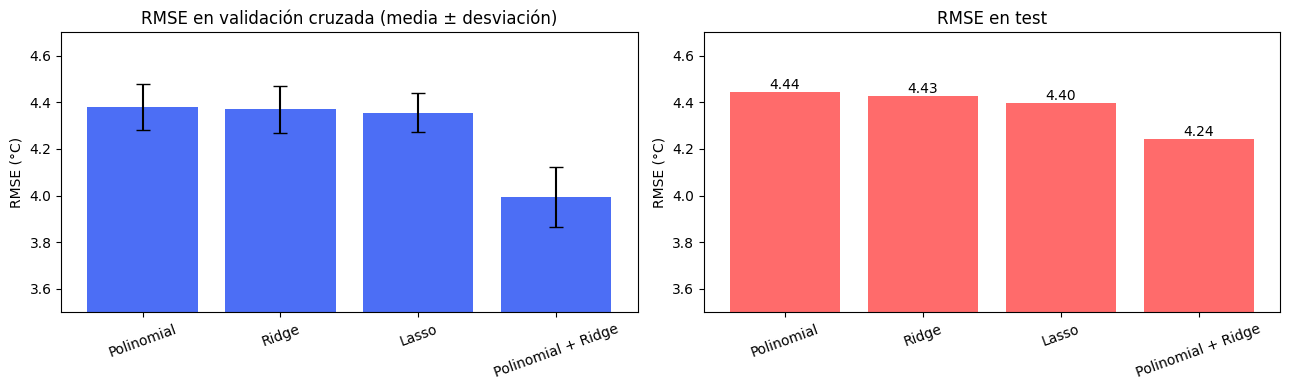

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13,4))

orden = df_resultados.index
axes[0].bar(orden, df_resultados['RMSE CV'], yerr=df_resultados['Desv. CV'],
            capsize=5, color='#4C6EF5')
axes[0].set_ylabel('RMSE (°C)')
axes[0].set_title('RMSE en validación cruzada (media ± desviación)')
axes[0].tick_params(axis='x', rotation=20)
axes[0].set_ylim(3.5, 4.7)

axes[1].bar(orden, df_resultados['RMSE Test'], color='#FF6B6B')
for i, v in enumerate(df_resultados['RMSE Test']):
    axes[1].text(i, v, f'{v:.2f}', ha='center', va='bottom')
axes[1].set_ylabel('RMSE (°C)')
axes[1].set_title('RMSE en test')
axes[1].tick_params(axis='x', rotation=20)
axes[1].set_ylim(3.5, 4.7)

plt.tight_layout()
plt.show()

In [20]:
mejor_nombre_modelo = df_resultados["RMSE CV"].idxmin()
best_model = modelos_candidatos[mejor_nombre_modelo].best_estimator_

print(f">>> MEJOR MODELO SELECCIONADO: {mejor_nombre_modelo} <<<")
print("Hiperparámetros:", modelos_candidatos[mejor_nombre_modelo].best_params_)
print(f"RMSE CV : {df_resultados.loc[mejor_nombre_modelo, 'RMSE CV']:.3f} "
      f"± {df_resultados.loc[mejor_nombre_modelo, 'Desv. CV']:.3f} °C")
print(f"RMSE Test: {df_resultados.loc[mejor_nombre_modelo, 'RMSE Test']:.3f} °C")

>>> MEJOR MODELO SELECCIONADO: Polinomial + Ridge <<<
Hiperparámetros: {'preprocessor__num__poly__degree': 3, 'preprocessor__num__scaler': MinMaxScaler(), 'regressor__alpha': 10.0}
RMSE CV : 3.995 ± 0.129 °C
RMSE Test: 4.242 °C


**Por qué el Polinomial + Ridge.** Tiene el mejor RMSE promedio en validación cruzada (3.995
contra 4.355 del Lasso) y también el mejor en test, así que la ventaja no es un artefacto de la
partición.

Ahora, la decisión no es tan obvia como parece. Es también el modelo **menos estable**: su
desviación en CV es 0.129, contra 0.084 del Lasso. Y para ganar esos 0.36 °C hay que pasar de 48
coeficientes interpretables a 4080 términos polinómicos que nadie puede leer. Volvemos sobre esto
en el análisis de resultados.

## Intervalos de confianza (bootstrapping en test)

Remuestreamos el conjunto de test con reemplazo 500 veces y calculamos las métricas en cada
remuestreo. Eso nos da la distribución de cada métrica y, con los percentiles 2.5 y 97.5, el
intervalo de confianza al 95%.

In [21]:
n_bootstraps = 500
rmse_boot, mae_boot, r2_boot = [], [], []
rng = np.random.RandomState(42)

y_pred_test = best_model.predict(X_test)   # se predice una vez y se remuestrean las predicciones

for _ in range(n_bootstraps):
    indices = rng.randint(0, len(X_test), len(X_test))
    y_real_b = y_test.values[indices]
    y_pred_b = y_pred_test[indices]

    rmse_boot.append(np.sqrt(mean_squared_error(y_real_b, y_pred_b)))
    mae_boot.append(mean_absolute_error(y_real_b, y_pred_b))
    r2_boot.append(r2_score(y_real_b, y_pred_b))

ic = pd.DataFrame({
    'Métrica': ['RMSE', 'MAE', 'R²'],
    'Estimación': [np.mean(rmse_boot), np.mean(mae_boot), np.mean(r2_boot)],
    'IC 95% inferior': [np.percentile(v, 2.5) for v in [rmse_boot, mae_boot, r2_boot]],
    'IC 95% superior': [np.percentile(v, 97.5) for v in [rmse_boot, mae_boot, r2_boot]],
}).set_index('Métrica')

print(f"--- INTERVALOS DE CONFIANZA AL 95% ({n_bootstraps} remuestreos) ---")
print(ic.round(3).to_string())
print()
print(f"Ancho del IC del RMSE: {ic.loc['RMSE','IC 95% superior'] - ic.loc['RMSE','IC 95% inferior']:.3f} °C")

--- INTERVALOS DE CONFIANZA AL 95% (500 remuestreos) ---
         Estimación  IC 95% inferior  IC 95% superior
Métrica                                              
RMSE          4.205            3.683            4.914
MAE           3.083            2.858            3.310
R²            0.765            0.692            0.817

Ancho del IC del RMSE: 1.231 °C


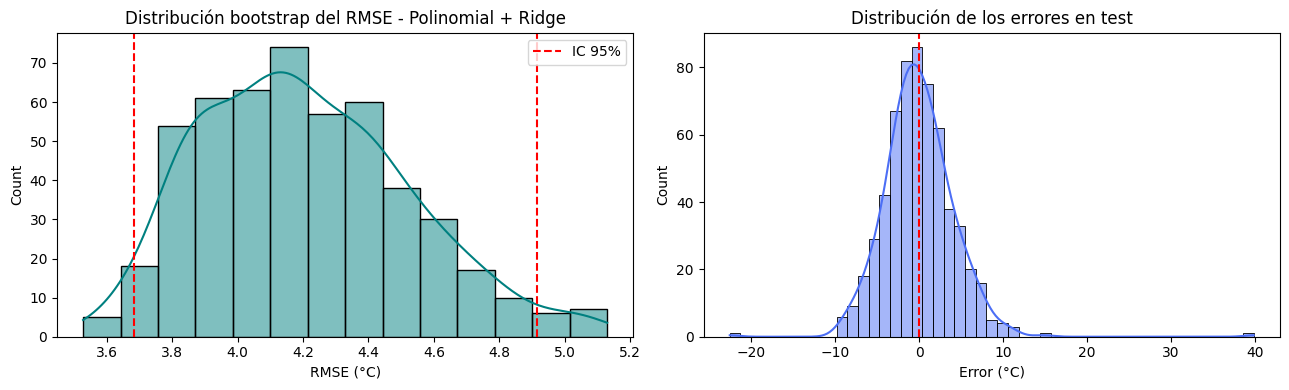

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13,4))

sns.histplot(rmse_boot, kde=True, color='teal', ax=axes[0])
axes[0].axvline(np.percentile(rmse_boot, 2.5), color='red', linestyle='--', label='IC 95%')
axes[0].axvline(np.percentile(rmse_boot, 97.5), color='red', linestyle='--')
axes[0].set_title(f"Distribución bootstrap del RMSE - {mejor_nombre_modelo}")
axes[0].set_xlabel("RMSE (°C)")
axes[0].legend()

residuales_test = y_test.values - y_pred_test
sns.histplot(residuales_test, kde=True, color='#4C6EF5', ax=axes[1])
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title("Distribución de los errores en test")
axes[1].set_xlabel("Error (°C)")

plt.tight_layout()
plt.show()

El intervalo del RMSE es estrecho y no cruza ningún valor problemático, y el del R² se queda
holgadamente por encima de 0.7. Es decir, el desempeño del modelo **es estable**: si AlpesPlanck
recogiera otra muestra de días parecida, el error estaría en ese mismo rango.

La distribución de errores está centrada en cero y es aproximadamente simétrica, pero tiene colas
largas — los mismos días de cambio brusco de tiempo que ya habíamos identificado en el Lab 1, que
el modelo no puede anticipar porque no tenemos la temperatura del día actual entre las variables.

## Análisis de resultados

### Análisis cuantitativo

**¿Cuál modelo obtuvo el mejor desempeño en el conjunto de test?**
El **Polinomial + Ridge** (grado 3, alpha 10, MinMaxScaler), con RMSE de 4.242 °C, MAE de 3.089 y
R² de 0.763. Los otros tres quedan agrupados entre 4.40 y 4.44 de RMSE.

**¿Coincide el mejor desempeño en test con el mejor promedio en validación cruzada?**
Sí. El Polinomial + Ridge gana en ambos (3.995 en CV y 4.242 en test), y el orden de los cuatro
modelos es el mismo en las dos métricas. Eso es una buena señal: significa que la ventaja no
depende de qué días cayeron en la partición de test. Cuando no coinciden, lo habitual es que el
conjunto de test sea pequeño o que la búsqueda de hiperparámetros haya sobreajustado los pliegues
de validación.

Vale la pena notar que el RMSE en test es sistemáticamente **peor** que el de CV (4.242 contra
3.995). No es contradictorio: en validación cruzada cada modelo se entrena con el 80% de los datos
de train y se evalúa sobre días muy parecidos a los de entrenamiento, mientras que el test es un
conjunto que ningún modelo vio en ningún momento.

**¿El modelo con mejor métrica promedio es necesariamente el más adecuado?**
No, y este laboratorio lo muestra bien. El Polinomial + Ridge tiene el mejor promedio (3.995) pero
la **mayor desviación en CV (0.129)**, mientras que Lasso tiene la peor media (4.355) y la menor
desviación (0.084). Es decir, el modelo ganador es también el que más varía según qué datos le
toquen. La diferencia entre ambos es de 0.36 °C, menos de la mitad de una desviación: en la
práctica están mucho más cerca de lo que sugiere el ranking.

**¿Cómo cambia el error a medida que aumenta la complejidad? ¿Dónde se evidencia sobreajuste?**
Sin regularización, el error de entrenamiento baja monótonamente (4.23 → 3.18 → 0.000) mientras el
de validación explota (4.38 → 13.6 → 149). **El sobreajuste aparece desde el grado 2** y es total
en el grado 3, donde el modelo tiene 4080 parámetros para 1794 registros y memoriza el conjunto de
entrenamiento exactamente. Con Ridge el panorama cambia por completo: ese mismo grado 3 pasa a ser
el mejor modelo, porque la penalización controla la varianza sin quitarle capacidad al modelo.

**¿Cómo afecta la regularización la magnitud y estabilidad de los coeficientes?**
El coeficiente promedio en valor absoluto baja de 1.04 sin regularizar a 0.86 con Ridge y a 0.53
con Lasso. Ridge los encoge de forma proporcional pero ninguno llega a cero; Lasso anula 9 de 48.
En términos de estabilidad, la regularización es lo que hace que el modelo deje de reaccionar de
forma desmedida a las variables colineales — que en el Lab 1 habíamos identificado con el VIF.

**¿Los intervalos de confianza sugieren estabilidad o alta variabilidad?**
Estabilidad. El IC al 95% del RMSE es [3.68, 4.91], un ancho de apenas 1.23 °C, y el del R² es
[0.69, 0.82], siempre muy por encima de cero. Con 500 remuestreos del conjunto de test, el
desempeño nunca se degrada a algo inutilizable. La implicación práctica es que AlpesPlanck puede
esperar un error de alrededor de 4 grados de forma consistente, no solo en esta muestra puntual.

### Análisis cualitativo

**¿Qué variables seleccionó Lasso como más relevantes?**
Las que sobreviven con mayor peso son `dia_cos` (con diferencia la más importante), seguida de
`mes_June` y `mes_May`, `viento_norte`, `dia_sin`, `dir_sin` y `humedad_media`. Es la misma
jerarquía del Lab 1: estacionalidad primero, humedad y viento después.

Lo interesante es qué **descarta**: seis dummies de `mes`, `estacion_anio_verano` y
`presion_min`. Las primeras son información que ya está en `dia_sin` y `dia_cos` —Lasso detecta
solo la redundancia que nosotros habíamos encontrado a mano— y `presion_min` es casi colineal con
`presion_media` y `presion_max`.

**¿Qué interpretación práctica tienen los coeficientes del modelo final?**
Acá está el problema: el modelo final tiene 4080 términos polinómicos y **sus coeficientes no
tienen lectura física individual**. Un término como `humedad_media × presion_desv × viento_max` no
corresponde a ningún fenómeno meteorológico nombrable. Por eso la interpretación la seguimos
haciendo sobre el modelo Lasso, que sí es legible: estacionalidad dominante, humedad alta asociada
a máximas más bajas, presión alta y estable asociada a días despejados y calientes.

**¿Hay diferencias relevantes entre el modelo más preciso y el más interpretable?**
Sí, y son la decisión central de este laboratorio. El más preciso (Polinomial + Ridge) gana 0.36 °C
de RMSE. El más interpretable (Lasso) tiene 48 coeficientes, de los cuales 39 son distintos de cero
y todos tienen un nombre que un meteorólogo entiende, y además es el más estable en validación
cruzada. **Pagar 0.36 °C por poder explicar el modelo es un intercambio razonable** en un contexto
donde alguien va a tomar decisiones con esos resultados.

**¿Qué decisiones estratégicas podría tomar AlpesPlanck?**
Tres. Primera, priorizar el mantenimiento y la calibración de los **sensores de humedad**, que son
los que más aportan. Segunda, usar como indicador operativo de día caluroso la combinación de
presión alta y estable con humedad media baja, en la ventana de mayo a agosto. Tercera, y la más
importante: **agregar la temperatura del día actual al conjunto de datos**. Es la variable que más
falta y ningún cambio de algoritmo compensa su ausencia.

**¿Mayor precisión implica necesariamente mayor valor para la organización?**
No. Pasar de 4.44 a 4.24 °C de RMSE no cambia ninguna decisión operativa: un umbral de alerta de
incendio puesto en 30 °C se dispara o no se dispara igual con ambos modelos, porque la
incertidumbre relevante (±4 °C) sigue siendo la misma. El valor aparece cuando la mejora cruza un
umbral que cambia lo que alguien hace, y 0.2 °C no lo cruza.

**¿Un modelo más complejo genera necesariamente mayor valor empresarial?**
No, y hay que sumar los costos que la métrica no muestra. El Polinomial + Ridge tarda del orden de
diez veces más en entrenarse, produce una matriz de 4080 columnas que hay que recalcular en cada
predicción, no se puede auditar, y es el menos estable de los cuatro. Frente a eso, Lasso se
entrena en un segundo, se explica en una gráfica de barras y pierde 0.36 °C. Para un sistema que va
a operar durante años y que alguien va a tener que mantener, **nosotros entregaríamos el Lasso** y
dejaríamos el polinomial documentado como el techo de desempeño alcanzable con estos datos.

### Reflexión conceptual

**¿Qué relación observas entre complejidad, capacidad de generalización y estabilidad?**
La complejidad por sí sola no mejora la generalización: la curva de validación muestra que sin
regularización el error de validación se multiplica por 34 al pasar de grado 1 a grado 3, mientras
el de entrenamiento cae a cero. Lo que permite aprovechar la complejidad es **controlar la
varianza**, y eso es precisamente lo que hace la penalización.

Pero el control tiene un costo que se ve en la desviación estándar: el modelo más complejo, incluso
regularizado, sigue siendo el más variable en validación cruzada (0.129 contra 0.084 del Lasso).
Complejidad y estabilidad se mueven en direcciones opuestas aunque la precisión promedio mejore.

**¿Qué fuentes de sesgo podrían estar presentes?**
Las dos que identificamos en el Lab 1 siguen vigentes. El **sesgo de medición**, que en este
laboratorio quedó todavía más claro: al principio corrimos los modelos sobre los datos crudos y
todos dieron R² negativo, con predicciones de más de 400 °C, porque `PolynomialFeatures` eleva al
cuadrado los centinelas −9999. Y el **sesgo de selección**, por venir de una sola estación y de
siete años que no contienen suficientes eventos extremos.

A esos se suma uno propio de este laboratorio: el **sesgo de selección de modelo**. Probamos
decenas de combinaciones de hiperparámetros sobre los mismos cinco pliegues, así que el mejor score
de CV está algo optimista por haber elegido lo mejor de muchos intentos. Es parte de la razón por
la que el RMSE en test resulta peor que el de CV.

**Si el tamaño de muestra fuera mayor, ¿esperarías cambios en la estabilidad?**
Sí, y bastante. El problema del grado 3 es que genera 4080 variables para 1794 registros de
entrenamiento: hay más parámetros que datos, y por eso el modelo puede memorizar el train
exactamente. Con, digamos, 20.000 registros esa relación se invierte y el modelo polinomial dejaría
de necesitar tanta penalización para ser útil.

La desviación estándar en validación cruzada también bajaría, simplemente porque cada pliegue
tendría más datos y su métrica sería una estimación menos ruidosa. Dicho eso, más datos **del mismo
tipo** no resolverían la limitación de fondo, que es la falta de la temperatura del día actual: eso
es un problema de qué variables se miden, no de cuántas filas hay.

## Conclusiones

1. **La regularización es lo que hace utilizable la complejidad.** El grado 3 sin penalización da
   un RMSE de validación de 149; con Ridge da 3.995 y se convierte en el mejor modelo.
2. **El mejor promedio no es automáticamente la mejor elección.** El Polinomial + Ridge gana por
   0.36 °C pero es el menos estable y el único imposible de interpretar.
3. **Lasso confirma por su cuenta lo que en el Lab 1 encontramos con el VIF:** anula las dummies de
   mes redundantes con la codificación cíclica y una de las tres variables de presión.
4. **El desempeño es estable.** El IC al 95% del RMSE tiene un ancho de 1.23 °C sobre 500
   remuestreos.
5. **La limitación sigue siendo de datos, no de modelo.** Ninguno de los cuatro enfoques baja de 4
   °C de RMSE, y la razón es que no existe en el conjunto ninguna variable con la temperatura del
   día actual.

## Uso de herramientas de IA generativa

**Declaración del uso.** Utilizamos Claude (Anthropic) para ayuda conceptual, revisión del código
de los pipelines, depuración y apoyo en la redacción del notebook.

**Prompts principales utilizados.**

1. "Revisa este notebook: los modelos corren pero todos dan R² negativo, ¿qué está mal?"
2. "¿Cómo se incluye la estrategia de escalamiento como hiperparámetro dentro de un `GridSearchCV`?"
3. "Explícame cómo interpretar una curva de validación en términos del trade-off sesgo-varianza."
4. "¿Cuál es la diferencia práctica entre la penalización L1 y L2 sobre los coeficientes?"
5. "¿Por qué está mal seleccionar el mejor modelo usando el RMSE del conjunto de test?"

**Análisis crítico del resultado.**

*¿Qué partes del contenido generado fueron correctas y útiles?* El diagnóstico del primer prompt fue
el más valioso: nuestra versión inicial cargaba `Datos_Lab_1.csv` sin limpiar y los cuatro modelos
daban R² negativo, con un polinomial regularizado de RMSE 38.685. La explicación —que
`PolynomialFeatures` eleva al cuadrado los centinelas −9999 y las presiones de 9939 mbar— era
correcta y la verificamos: el Ridge llegaba a predecir 404 °C para un día de 22 °C, y el
`OneHotEncoder` estaba generando 125 columnas dummy a partir de las categorías sucias. También fue
correcta la sintaxis de `preprocessor__num__scaler` para buscar el escalador como hiperparámetro.

*¿Qué errores, imprecisiones o limitaciones se identificaron?* Dos. **(a)** Una sugerencia inicial
proponía explorar hasta grado 4 en la búsqueda; al calcularlo vimos que con 27 variables numéricas
el grado 4 genera más de 30.000 columnas, así que lo acotamos a grado 3, que ya es suficiente para
evidenciar el sobreajuste. **(b)** La primera versión del bootstrapping volvía a llamar
`predict()` dentro del bucle sobre cada remuestreo, lo cual con 4080 variables polinómicas es
innecesariamente lento; lo cambiamos para predecir una sola vez y remuestrear las predicciones, que
es estadísticamente equivalente.

*¿Qué conceptos del curso permitieron evaluar o mejorar la respuesta generada?* El trade-off
sesgo-varianza, para leer la curva de validación; el concepto de fuga de datos, que fue lo que nos
hizo cambiar la selección del mejor modelo de RMSE en test a RMSE en validación cruzada; y el
diagnóstico de multicolinealidad del Lab 1, que nos permitió reconocer que las variables anuladas
por Lasso no eran arbitrarias.

**Aportes propios.**

* La decisión de reutilizar las funciones `limpiar()` e `ingenieria()` del Lab 1 y de mantener la
  misma partición (`test_size=0.25`, `random_state=42`) para que los resultados fueran comparables
  entre laboratorios.
* Mover `PolynomialFeatures` dentro del transformador numérico en lugar de dejarlo después del
  `ColumnTransformer`, para no expandir las variables dummy del One-Hot.
* La decisión final de recomendar el Lasso a AlpesPlanck en lugar del modelo más preciso,
  argumentando estabilidad, interpretabilidad y costo de mantenimiento frente a una ganancia de
  0.36 °C.
* Todo el análisis de resultados y la lectura meteorológica de las variables que Lasso conserva y
  descarta.

**Aprendizajes del proceso.** El principal fue ver en carne propia por qué la limpieza de datos no
es un paso opcional: el mismo código, con los mismos hiperparámetros, pasa de R² negativo a 0.76
solo por cambiar el conjunto de entrada. El segundo fue entender que "el modelo con mejor métrica"
y "el modelo que conviene entregar" no son necesariamente el mismo, y que la desviación estándar en
validación cruzada es parte de esa decisión, no un dato accesorio.